# 05. Transportability and External Validity

A causal estimate can be internally valid and still be the wrong estimate for the decision.

Randomization protects the comparison inside a trial or experiment. It does not guarantee that the people, customers, stores, hospitals, regions, or accounts in the experiment represent the population where the intervention will be deployed.

This notebook is about moving from:

$$
\text{What was the effect in the study sample?}
$$

to:

$$
\text{What would the effect be in the target population?}
$$

That move is called generalizability or transportability, depending on the design. We will use simulations to study why the distinction matters, how effect modification drives the problem, and how standardization, inverse probability of sampling weights, subclassification, and doubly robust estimators can help.


## Learning Goals

By the end of this notebook, you should be able to:

- Distinguish internal validity from external validity.
- Define sample average treatment effects and target population average treatment effects.
- Explain why sample imbalance matters mainly when treatment effects are heterogeneous.
- Draw a selection diagram for trial participation or pilot inclusion.
- State the assumptions needed to extend trial evidence to a target population.
- Estimate a target population effect using standardization, inverse probability of sampling weights, subclassification, and a doubly robust estimator.
- Diagnose poor overlap between a study sample and a target population.
- Run a sensitivity analysis for unmeasured effect modifiers.
- Write an industry memo about whether an experiment should be generalized to deployment.


## 1. Setup

We will use pandas, numpy, statsmodels, seaborn, matplotlib, and Graphviz.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from graphviz import Digraph
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.special import expit
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    return np.sum(weights * values) / np.sum(weights)


def weighted_var(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mean = weighted_mean(values, weights)
    return np.sum(weights * (values - mean) ** 2) / np.sum(weights)


def mean_difference(df, outcome, treatment, weights=None):
    treated = df[treatment] == 1
    control = df[treatment] == 0
    if weights is None:
        return df.loc[treated, outcome].mean() - df.loc[control, outcome].mean()
    return (
        weighted_mean(df.loc[treated, outcome], weights.loc[treated])
        - weighted_mean(df.loc[control, outcome], weights.loc[control])
    )


def standardized_mean_difference(trial_values, target_values, trial_weights=None):
    if trial_weights is None:
        trial_mean = np.mean(trial_values)
        trial_var = np.var(trial_values, ddof=1)
    else:
        trial_mean = weighted_mean(trial_values, trial_weights)
        trial_var = weighted_var(trial_values, trial_weights)
    target_mean = np.mean(target_values)
    target_var = np.var(target_values, ddof=1)
    return (trial_mean - target_mean) / np.sqrt((trial_var + target_var) / 2)


## 2. Internal Validity Is Not External Validity

Internal validity asks whether the comparison identifies a causal effect in the study sample.

External validity asks whether that effect is relevant for a target population.

Let $S=1$ indicate participation in a study or pilot. A randomized trial can identify:

$$
SATE = E[Y(1) - Y(0) \mid S=1]
$$

But a deployment decision may need:

$$
TATE = E[Y(1) - Y(0)]
$$

in the target population.

These are equal only under additional conditions. The most important practical condition is that study participation does not change the distribution of effect modifiers, or that treatment effects are constant across the differences that exist.


In [2]:
validity_table = pd.DataFrame(
    [
        {
            "question": "Internal validity",
            "asks": "Did the study estimate a causal effect for the study sample?",
            "common threats": "Confounding, noncompliance, attrition, interference, measurement error",
            "industry example": "Did the A/B test estimate the effect among users included in the test?",
        },
        {
            "question": "External validity",
            "asks": "Does that effect apply to the population where we will act?",
            "common threats": "Selective pilot sites, customer mix shift, geography, seasonality, maturity, channel differences",
            "industry example": "Will the same product change work for all customers after global rollout?",
        },
    ]
)

validity_table


,question,asks,common threats,industry example
0,Internal validity,Did the study estimate a causal effect for the...,"Confounding, noncompliance, attrition, interfe...",Did the A/B test estimate the effect among use...
1,External validity,Does that effect apply to the population where...,"Selective pilot sites, customer mix shift, geo...",Will the same product change work for all cust...


## 3. Generalizability vs Transportability

The terminology varies across fields, but a useful working distinction is:

- **Generalizability**: the study participants are sampled from, or nested in, a defined target population.
- **Transportability**: the study population and target population are distinct populations or environments.

The methods overlap, but the design questions differ.


In [3]:
design_table = pd.DataFrame(
    [
        {
            "design": "Nested trial",
            "data structure": "Trial participants are inside an enumerated target population.",
            "example": "A product experiment among a subset of eligible users in a platform.",
            "main need": "Covariates for trial participants and nonparticipants.",
        },
        {
            "design": "Composite dataset",
            "data structure": "Trial data plus a separate target-population sample.",
            "example": "A vendor pilot plus a CRM sample of all future accounts.",
            "main need": "Comparable covariates measured in both datasets.",
        },
        {
            "design": "Transport from one environment",
            "data structure": "Source experiment and target environment differ.",
            "example": "A US market experiment used for an EU launch decision.",
            "main need": "Knowledge of which mechanisms differ across environments.",
        },
        {
            "design": "Multiple trials or sites",
            "data structure": "Several source studies, each with different populations.",
            "example": "Regional pilots used to inform national rollout.",
            "main need": "Site-level and unit-level effect modifiers.",
        },
    ]
)

design_table


,design,data structure,example,main need
0,Nested trial,Trial participants are inside an enumerated ta...,A product experiment among a subset of eligibl...,Covariates for trial participants and nonparti...
1,Composite dataset,Trial data plus a separate target-population s...,A vendor pilot plus a CRM sample of all future...,Comparable covariates measured in both datasets.
2,Transport from one environment,Source experiment and target environment differ.,A US market experiment used for an EU launch d...,Knowledge of which mechanisms differ across en...
3,Multiple trials or sites,"Several source studies, each with different po...",Regional pilots used to inform national rollout.,Site-level and unit-level effect modifiers.


Cole and Stuart (2010), Tipton (2013), Buchanan et al. (2018), and Dahabreh et al. (2021) give modern statistical treatments of extending randomized trial evidence to target populations. Pearl and Bareinboim (2011) formalize transportability with selection diagrams, which represent where environments differ.


## 4. Selection Diagrams

A selection diagram adds nodes that indicate differences between the study environment and target environment.

Here, $X$ is a set of baseline covariates. These covariates affect trial participation and also modify the treatment effect. Trial participation $S$ does not cause the potential outcomes; rather, it changes which covariate profiles we observe in the experiment.


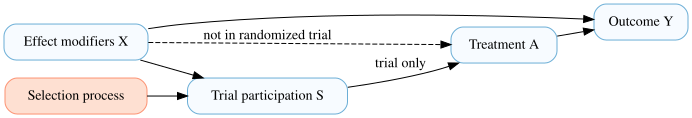

In [4]:
dot = Digraph("selection_diagram", graph_attr={"rankdir": "LR"})
dot.attr("node", shape="box", style="rounded,filled", fillcolor="#f7fbff", color="#6baed6")

dot.node("X", "Effect modifiers X")
dot.node("S", "Trial participation S")
dot.node("A", "Treatment A")
dot.node("Y", "Outcome Y")
dot.node("Sel", "Selection process", fillcolor="#fee0d2", color="#fc9272")

dot.edge("X", "S")
dot.edge("X", "Y")
dot.edge("X", "A", style="dashed", label="not in randomized trial")
dot.edge("Sel", "S")
dot.edge("A", "Y")
dot.edge("S", "A", label="trial only")

dot


The diagram says:

- Within the trial, treatment is randomized.
- Trial participation depends on covariates.
- Those covariates are also related to the outcome and may modify the treatment effect.

This is the classic setup where the trial estimate can be internally valid but externally biased for the target population.


## 5. Assumptions for Extending Trial Evidence

A common identification strategy relies on:


In [5]:
assumption_table = pd.DataFrame(
    [
        {
            "assumption": "Consistency",
            "meaning": "Observed outcomes under received treatment equal the relevant potential outcomes.",
            "practical question": "Is the intervention version in the pilot the same version planned for rollout?",
        },
        {
            "assumption": "Trial exchangeability",
            "meaning": "Within the trial, treatment is independent of potential outcomes given design.",
            "practical question": "Was treatment truly randomized or otherwise ignorable in the study?",
        },
        {
            "assumption": "Treatment positivity",
            "meaning": "Every relevant covariate profile in the trial can receive each treatment.",
            "practical question": "Did randomization assign both variants across all important subgroups?",
        },
        {
            "assumption": "Conditional generalizability",
            "meaning": "Given measured X, trial participation is independent of treatment effects.",
            "practical question": "Have we measured the variables that explain why effects differ between trial and target?",
        },
        {
            "assumption": "Sampling positivity",
            "meaning": "Target profiles have positive chance of trial participation.",
            "practical question": "Do we have pilot evidence for the kinds of units we will deploy to?",
        },
        {
            "assumption": "Measurement alignment",
            "meaning": "Covariates, treatments, and outcomes mean the same thing in study and target data.",
            "practical question": "Are logging systems and business definitions aligned across environments?",
        },
    ]
)

assumption_table


,assumption,meaning,practical question
0,Consistency,Observed outcomes under received treatment equ...,Is the intervention version in the pilot the s...
1,Trial exchangeability,"Within the trial, treatment is independent of ...",Was treatment truly randomized or otherwise ig...
2,Treatment positivity,Every relevant covariate profile in the trial ...,Did randomization assign both variants across ...
3,Conditional generalizability,"Given measured X, trial participation is indep...",Have we measured the variables that explain wh...
4,Sampling positivity,Target profiles have positive chance of trial ...,Do we have pilot evidence for the kinds of uni...
5,Measurement alignment,"Covariates, treatments, and outcomes mean the ...",Are logging systems and business definitions a...


The conditional generalizability condition is often written:

$$
Y(a) \perp S \mid X
$$

for each treatment level $a$.

That does not say trial participants and nonparticipants are identical. It says that after conditioning on measured effect modifiers $X$, participation does not carry additional information about potential outcomes under treatment $a$.


## 6. Simulation: A Pilot That Overrepresents Low-Risk Customers

Imagine a company pilots a retention intervention.

The target population contains all customers eligible for deployment. The pilot overrepresents enterprise customers, high-usage customers, and lower-risk customers. The treatment effect is heterogeneous: it is larger for enterprise customers and high-prior-usage customers, but smaller for older and higher-risk customers.

We will generate the full target population, select a nonrandom pilot sample, randomize treatment inside the pilot, and observe outcomes only inside the pilot.


In [6]:
rng = np.random.default_rng(4505)
n_target = 40_000

target = pd.DataFrame(
    {
        "age": np.clip(rng.normal(47, 12, size=n_target), 18, 80),
    }
)

target["enterprise"] = rng.binomial(1, expit(-0.7 + 0.025 * (target["age"] - 45)), size=n_target)
target["risk"] = rng.normal(0.15 * target["enterprise"] + 0.018 * (target["age"] - 45), 1.0, size=n_target)
target["prior_usage"] = rng.normal(0.55 * target["enterprise"] - 0.35 * target["risk"], 1.0, size=n_target)

target["baseline_outcome"] = (
    18
    + 0.08 * target["age"]
    - 1.4 * target["risk"]
    + 1.8 * target["enterprise"]
    + 1.6 * target["prior_usage"]
    + rng.normal(0, 3.0, size=n_target)
)

target["tau"] = (
    2.4
    - 0.030 * (target["age"] - 45)
    - 0.80 * target["risk"]
    + 0.75 * target["enterprise"]
    + 0.45 * target["prior_usage"]
)

target["Y0"] = target["baseline_outcome"]
target["Y1"] = target["Y0"] + target["tau"]

target["p_trial"] = expit(
    -1.65
    - 0.035 * (target["age"] - 45)
    - 0.90 * target["risk"]
    + 0.60 * target["enterprise"]
    + 0.35 * target["prior_usage"]
)
target["S"] = rng.binomial(1, target["p_trial"])
target["A"] = np.where(target["S"] == 1, rng.binomial(1, 0.5, size=n_target), np.nan)
target["Y"] = np.where(
    target["S"] == 1,
    target["Y0"] + target["A"] * target["tau"],
    np.nan,
)

trial = target.loc[target["S"] == 1].copy()

overview = pd.Series(
    {
        "target_n": len(target),
        "trial_n": len(trial),
        "trial_share": target["S"].mean(),
        "true_target_ate": target["tau"].mean(),
        "true_trial_sate": trial["tau"].mean(),
        "observed_trial_difference": mean_difference(trial, "Y", "A"),
    }
)

overview


target_n                    40,000.000
trial_n                      9,330.000
trial_share                      0.233
true_target_ate                  2.599
true_trial_sate                  3.538
observed_trial_difference        3.550
dtype: float64

The true target effect and the true trial-sample effect differ because the trial sample is not a random sample of the target population and the effect varies with covariates.


In [7]:
composition = pd.DataFrame(
    {
        "Target population": target[["age", "risk", "enterprise", "prior_usage", "tau"]].mean(),
        "Trial sample": trial[["age", "risk", "enterprise", "prior_usage", "tau"]].mean(),
    }
)
composition["trial_minus_target"] = composition["Trial sample"] - composition["Target population"]
composition


,Target population,Trial sample,trial_minus_target
age,47.058,42.932,-4.127
risk,0.088,-0.596,-0.684
enterprise,0.347,0.407,0.060
prior_usage,0.156,0.652,0.497
tau,2.599,3.538,0.939


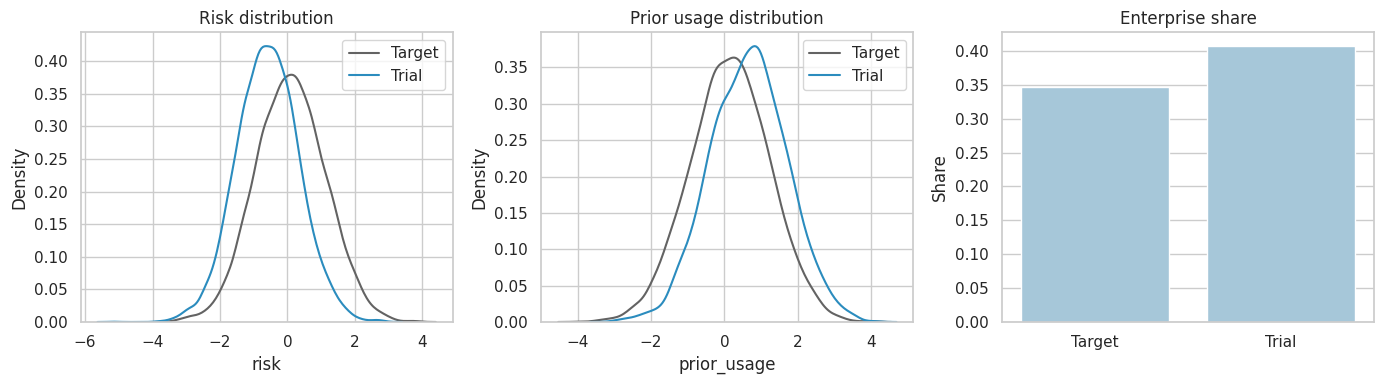

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.kdeplot(data=target.sample(6000, random_state=1), x="risk", ax=axes[0], label="Target", color="#636363")
sns.kdeplot(data=trial.sample(min(6000, len(trial)), random_state=2), x="risk", ax=axes[0], label="Trial", color="#2b8cbe")
axes[0].set_title("Risk distribution")
axes[0].legend()

sns.kdeplot(data=target.sample(6000, random_state=3), x="prior_usage", ax=axes[1], label="Target", color="#636363")
sns.kdeplot(data=trial.sample(min(6000, len(trial)), random_state=4), x="prior_usage", ax=axes[1], label="Trial", color="#2b8cbe")
axes[1].set_title("Prior usage distribution")
axes[1].legend()

plot_df = pd.DataFrame(
    {
        "population": ["Target", "Trial"],
        "enterprise_share": [target["enterprise"].mean(), trial["enterprise"].mean()],
    }
)
sns.barplot(data=plot_df, x="population", y="enterprise_share", ax=axes[2], color="#9ecae1")
axes[2].set_title("Enterprise share")
axes[2].set_xlabel("")
axes[2].set_ylabel("Share")

plt.tight_layout()
plt.show()


## 7. When Does Sample Imbalance Matter?

Sample imbalance matters for the target effect when the imbalanced variables are effect modifiers.

If the treatment effect were constant:

$$
Y(1) - Y(0) = \tau
$$

then the trial sample and target population would have the same average effect even if their covariates differed.

When effects are heterogeneous:

$$
Y(1) - Y(0) = \tau(X)
$$

the target effect depends on the target distribution of $X$:

$$
E[\tau(X)]
$$


In [9]:
rng = np.random.default_rng(4506)
constant_effect = 2.4
target["Y_const"] = np.where(
    target["S"] == 1,
    target["Y0"] + target["A"] * constant_effect,
    np.nan,
)

heterogeneity_message = pd.DataFrame(
    [
        {
            "scenario": "Constant effect",
            "true_target_effect": constant_effect,
            "true_trial_effect": constant_effect,
            "observed_trial_difference": mean_difference(target.loc[target["S"] == 1], "Y_const", "A"),
        },
        {
            "scenario": "Heterogeneous effect",
            "true_target_effect": target["tau"].mean(),
            "true_trial_effect": trial["tau"].mean(),
            "observed_trial_difference": mean_difference(trial, "Y", "A"),
        },
    ]
)

heterogeneity_message


,scenario,true_target_effect,true_trial_effect,observed_trial_difference
0,Constant effect,2.400,2.400,2.424
1,Heterogeneous effect,2.599,3.538,3.550


The same selective trial sample is harmless in the constant-effect case and problematic in the heterogeneous-effect case. That is why external-validity analysis is fundamentally about effect modifiers, not every baseline difference.


## 8. Method 1: Outcome-Model Standardization

Standardization fits an outcome model in the trial and averages predicted potential outcomes over the target population.

For each target unit, estimate:

$$
\widehat{m}_a(X) = \widehat{E}[Y \mid A=a, X, S=1]
$$

Then estimate:

$$
\widehat{TATE}_{std}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left[
\widehat{m}_1(X_i) - \widehat{m}_0(X_i)
\right]
$$

This works when the outcome model captures the relevant treatment-effect heterogeneity and the trial has support for the target covariate profiles.


In [10]:
outcome_model = smf.ols(
    "Y ~ A * (age + risk + enterprise + prior_usage)",
    data=trial,
).fit()

target["m1"] = outcome_model.predict(target.assign(A=1.0))
target["m0"] = outcome_model.predict(target.assign(A=0.0))
standardized_estimate = (target["m1"] - target["m0"]).mean()

standardization_table = pd.DataFrame(
    {
        "quantity": [
            "True target ATE",
            "True trial SATE",
            "Observed trial difference",
            "Standardized target estimate",
        ],
        "estimate": [
            target["tau"].mean(),
            trial["tau"].mean(),
            mean_difference(trial, "Y", "A"),
            standardized_estimate,
        ],
    }
)
standardization_table["error_vs_true_target"] = standardization_table["estimate"] - target["tau"].mean()
standardization_table


,quantity,estimate,error_vs_true_target
0,True target ATE,2.599,0.000
1,True trial SATE,3.538,0.939
2,Observed trial difference,3.550,0.952
3,Standardized target estimate,2.730,0.132


Standardization changes the estimand by averaging trial-learned conditional effects over the target distribution rather than the trial distribution.


## 9. Method 2: Inverse Probability of Sampling Weights

Inverse probability of sampling weighting estimates how likely each target unit was to be included in the trial:

$$
e_S(X) = P(S=1 \mid X)
$$

Trial participants who look underrepresented relative to the target get larger weights:

$$
w_i = \frac{1}{\widehat{e}_S(X_i)}
$$

The weighted trial distribution should resemble the target population distribution.


In [11]:
sampling_model = smf.logit(
    "S ~ age + risk + enterprise + prior_usage",
    data=target,
).fit(disp=0)

target["pS_hat"] = np.clip(sampling_model.predict(target), 0.02, 0.98)
trial = target.loc[target["S"] == 1].copy()
trial["transport_weight"] = 1 / trial["pS_hat"]

ipw_estimate = mean_difference(trial, "Y", "A", weights=trial["transport_weight"])

weight_summary = trial["transport_weight"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame("transport_weight")
weight_summary


,transport_weight
count,"9,330.000"
mean,4.206
std,4.646
min,1.020
50%,2.755
90%,8.223
95%,11.786
99%,22.384
max,50.000


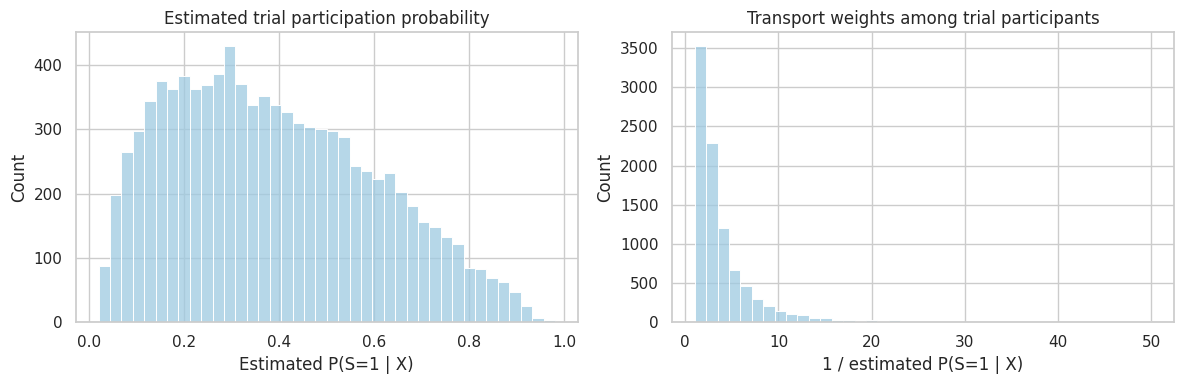

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(trial["pS_hat"], bins=40, ax=axes[0], color="#9ecae1")
axes[0].set_title("Estimated trial participation probability")
axes[0].set_xlabel("Estimated P(S=1 | X)")

sns.histplot(trial["transport_weight"], bins=40, ax=axes[1], color="#9ecae1")
axes[1].set_title("Transport weights among trial participants")
axes[1].set_xlabel("1 / estimated P(S=1 | X)")

plt.tight_layout()
plt.show()


Weights are a design diagnostic as much as an estimator. Very large weights mean the trial contains only a small number of participants who represent large portions of the target population.


## 10. Balance Diagnostics

After weighting, the trial covariate distribution should look more like the target distribution.

We can use standardized mean differences:

$$
SMD =
\frac{\bar{X}_{trial} - \bar{X}_{target}}
\sqrt{(s^2_{trial} + s^2_{target})/2}}
$$

For weighted trial means, replace the trial mean and variance with weighted versions.


In [13]:
balance_rows = []
for covariate in ["age", "risk", "enterprise", "prior_usage"]:
    balance_rows.append(
        {
            "covariate": covariate,
            "target_mean": target[covariate].mean(),
            "trial_mean_unweighted": trial[covariate].mean(),
            "trial_mean_weighted": weighted_mean(trial[covariate], trial["transport_weight"]),
            "smd_unweighted": standardized_mean_difference(trial[covariate], target[covariate]),
            "smd_weighted": standardized_mean_difference(
                trial[covariate],
                target[covariate],
                trial_weights=trial["transport_weight"],
            ),
        }
    )

balance_table = pd.DataFrame(balance_rows)
balance_table


,covariate,target_mean,trial_mean_unweighted,trial_mean_weighted,smd_unweighted,smd_weighted
0,age,47.058,42.932,46.821,-0.351,-0.020
1,risk,0.088,-0.596,0.048,-0.703,-0.040
2,enterprise,0.347,0.407,0.353,0.123,0.011
3,prior_usage,0.156,0.652,0.181,0.469,0.023


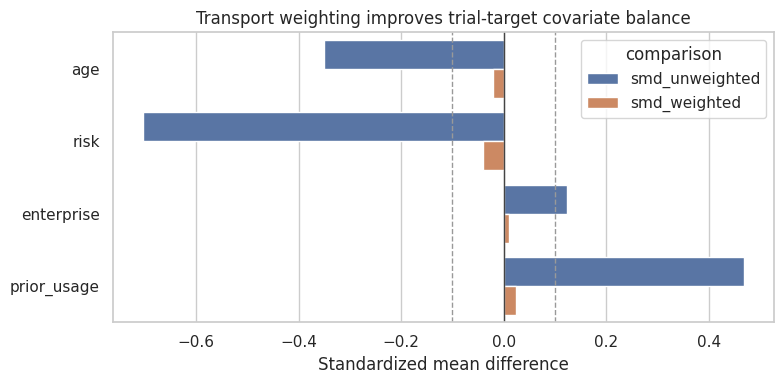

In [14]:
balance_plot = balance_table.melt(
    id_vars="covariate",
    value_vars=["smd_unweighted", "smd_weighted"],
    var_name="comparison",
    value_name="smd",
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=balance_plot, y="covariate", x="smd", hue="comparison", ax=ax)
ax.axvline(0, color="#444444", linewidth=1)
ax.axvline(0.1, color="#999999", linestyle="--", linewidth=1)
ax.axvline(-0.1, color="#999999", linestyle="--", linewidth=1)
ax.set_title("Transport weighting improves trial-target covariate balance")
ax.set_xlabel("Standardized mean difference")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


Balance is not proof of validity. It only checks measured covariates. But poor balance after weighting is a clear warning that the sampling model or support is inadequate.


## 11. Method 3: Sampling-Score Subclassification

Tipton (2013) discusses propensity-score subclassification for improving generalizations from experiments.

The idea is to group units by similar sampling scores. Within each group, estimate the treatment effect in the trial, then average those group-specific effects using target-population group shares.


In [15]:
target["sampling_score_quintile"] = pd.qcut(target["pS_hat"], q=5, labels=False, duplicates="drop")
trial = target.loc[target["S"] == 1].copy()

subclass_rows = []
for score_bin, target_bin in target.groupby("sampling_score_quintile"):
    trial_bin = trial.loc[trial["sampling_score_quintile"] == score_bin]
    if trial_bin["A"].nunique() < 2:
        effect_estimate = np.nan
    else:
        effect_estimate = mean_difference(trial_bin, "Y", "A")
    subclass_rows.append(
        {
            "score_bin": int(score_bin),
            "target_n": len(target_bin),
            "trial_n": len(trial_bin),
            "target_share": len(target_bin) / len(target),
            "trial_share": len(trial_bin) / len(trial),
            "true_bin_tau": target_bin["tau"].mean(),
            "trial_effect_estimate": effect_estimate,
        }
    )

subclass_table = pd.DataFrame(subclass_rows)
subclass_estimate = np.sum(subclass_table["target_share"] * subclass_table["trial_effect_estimate"])
subclass_table


,score_bin,target_n,trial_n,target_share,trial_share,true_bin_tau,trial_effect_estimate
0,0,8000,297,0.200,0.032,0.884,1.661
1,1,8000,825,0.200,0.088,1.948,2.216
2,2,8000,1469,0.200,0.157,2.603,2.870
3,3,8000,2375,0.200,0.255,3.254,3.407
4,4,8000,4364,0.200,0.468,4.304,4.314


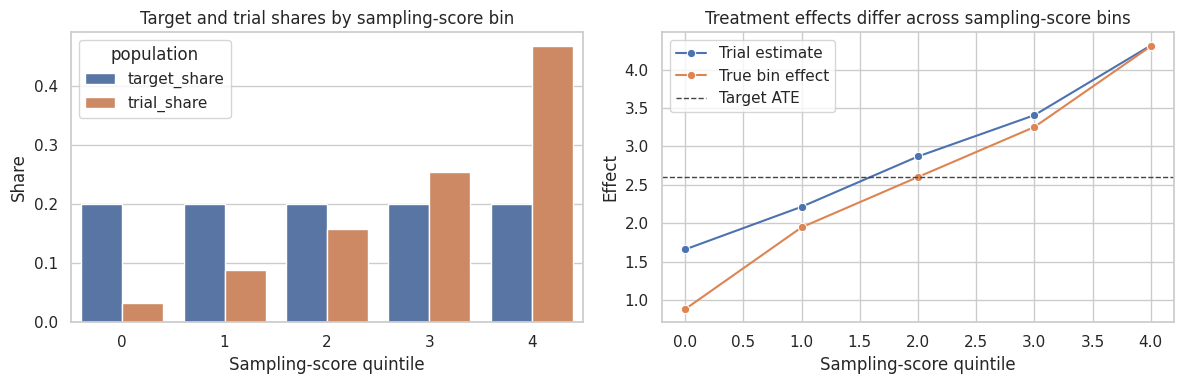

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

share_plot = subclass_table.melt(
    id_vars="score_bin",
    value_vars=["target_share", "trial_share"],
    var_name="population",
    value_name="share",
)
sns.barplot(data=share_plot, x="score_bin", y="share", hue="population", ax=axes[0])
axes[0].set_title("Target and trial shares by sampling-score bin")
axes[0].set_xlabel("Sampling-score quintile")
axes[0].set_ylabel("Share")

sns.lineplot(data=subclass_table, x="score_bin", y="trial_effect_estimate", marker="o", ax=axes[1], label="Trial estimate")
sns.lineplot(data=subclass_table, x="score_bin", y="true_bin_tau", marker="o", ax=axes[1], label="True bin effect")
axes[1].axhline(target["tau"].mean(), color="#444444", linestyle="--", linewidth=1, label="Target ATE")
axes[1].set_title("Treatment effects differ across sampling-score bins")
axes[1].set_xlabel("Sampling-score quintile")
axes[1].set_ylabel("Effect")
axes[1].legend()

plt.tight_layout()
plt.show()


Subclassification is transparent and easy to explain. Its weakness is that it can be coarse, especially when important effect modifiers are continuous or when some subclasses have few treated or control units.


## 12. Method 4: Doubly Robust Transport Estimator

A doubly robust estimator combines:

1. an outcome model, and
2. a sampling model.

One version estimates each target potential outcome mean as:

$$
\widehat{\mu}_a =
\frac{1}{N}\sum_{i=1}^{N}\widehat{m}_a(X_i)
+
\frac{1}{N}\sum_{i:S_i=1}
\frac{I(A_i=a)}{\widehat{P}(S_i=1 \mid X_i)\widehat{P}(A_i=a)}
\left[
Y_i-\widehat{m}_a(X_i)
\right]
$$

Then:

$$
\widehat{TATE}_{DR} = \widehat{\mu}_1 - \widehat{\mu}_0
$$

The estimator uses the target population to average predictions and uses trial residuals to correct them.


In [17]:
pA = 0.5
target["m1"] = outcome_model.predict(target.assign(A=1.0))
target["m0"] = outcome_model.predict(target.assign(A=0.0))
trial = target.loc[target["S"] == 1].copy()

mu1_dr = (
    target["m1"].mean()
    + (((trial["A"] == 1) * (trial["Y"] - trial["m1"]) / (trial["pS_hat"] * pA)).sum() / len(target))
)
mu0_dr = (
    target["m0"].mean()
    + (((trial["A"] == 0) * (trial["Y"] - trial["m0"]) / (trial["pS_hat"] * (1 - pA))).sum() / len(target))
)
dr_estimate = mu1_dr - mu0_dr

transport_results = pd.DataFrame(
    [
        {"method": "True target ATE", "estimate": target["tau"].mean()},
        {"method": "True trial SATE", "estimate": trial["tau"].mean()},
        {"method": "Observed trial difference", "estimate": mean_difference(trial, "Y", "A")},
        {"method": "Outcome-model standardization", "estimate": standardized_estimate},
        {"method": "Inverse sampling-weight estimate", "estimate": ipw_estimate},
        {"method": "Sampling-score subclassification", "estimate": subclass_estimate},
        {"method": "Doubly robust transport estimate", "estimate": dr_estimate},
    ]
)
transport_results["error_vs_true_target"] = transport_results["estimate"] - target["tau"].mean()
transport_results


,method,estimate,error_vs_true_target
0,True target ATE,2.599,0.000
1,True trial SATE,3.538,0.939
2,Observed trial difference,3.550,0.952
3,Outcome-model standardization,2.730,0.132
4,Inverse sampling-weight estimate,2.841,0.243
5,Sampling-score subclassification,2.894,0.295
6,Doubly robust transport estimate,2.726,0.127


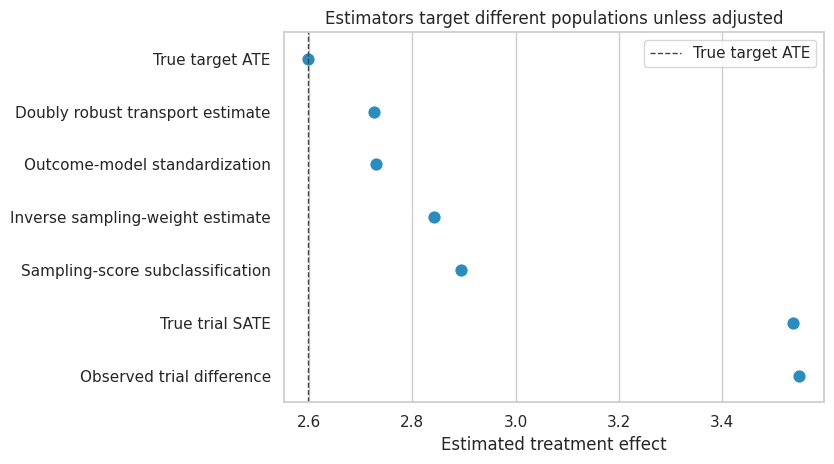

In [18]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
plot_df = transport_results.sort_values("estimate")
sns.pointplot(data=plot_df, y="method", x="estimate", join=False, ax=ax, color="#2b8cbe")
ax.axvline(target["tau"].mean(), color="#444444", linestyle="--", linewidth=1, label="True target ATE")
ax.set_title("Estimators target different populations unless adjusted")
ax.set_xlabel("Estimated treatment effect")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
plt.show()


### Interpretation

The unadjusted trial estimate is close to the trial-sample effect. The transported estimators move toward the target effect because they reweight or re-average the trial information to match the target population.

In real projects, we do not know the true target effect. That is why design diagnostics are so important:

- Are the effect modifiers measured?
- Are covariate distributions balanced after weighting?
- Are weights stable?
- Does the trial cover the target support?
- Are treatment and outcome definitions aligned across environments?


## 13. Positivity and Support

Transportability fails when the target population contains covariate profiles that the trial never studied.

This is not just a small-sample problem. It is an identification problem.

If high-risk customers were never included in the pilot, then the pilot cannot empirically tell us the treatment effect for high-risk customers without extrapolation.


In [19]:
rng = np.random.default_rng(4510)

target["pilot_support"] = (target["age"] <= 60) & (target["risk"] <= 1.20)
target["S_limited"] = rng.binomial(1, np.where(target["pilot_support"], 0.24, 0.0))
limited_trial = target.loc[target["S_limited"] == 1].copy()
limited_trial["A_limited"] = rng.binomial(1, 0.5, size=len(limited_trial))
limited_trial["Y_limited"] = limited_trial["Y0"] + limited_trial["A_limited"] * limited_trial["tau"]

support_summary = pd.DataFrame(
    {
        "quantity": [
            "Target share outside pilot support",
            "Limited pilot sample size",
            "True target ATE",
            "True ATE among support-covered target units",
            "True ATE among limited pilot participants",
        ],
        "value": [
            (~target["pilot_support"]).mean(),
            len(limited_trial),
            target["tau"].mean(),
            target.loc[target["pilot_support"], "tau"].mean(),
            limited_trial["tau"].mean(),
        ],
    }
)

support_summary


,quantity,value
0,Target share outside pilot support,0.246
1,Limited pilot sample size,"7,174.000"
2,True target ATE,2.599
3,True ATE among support-covered target units,2.955
4,True ATE among limited pilot participants,2.955


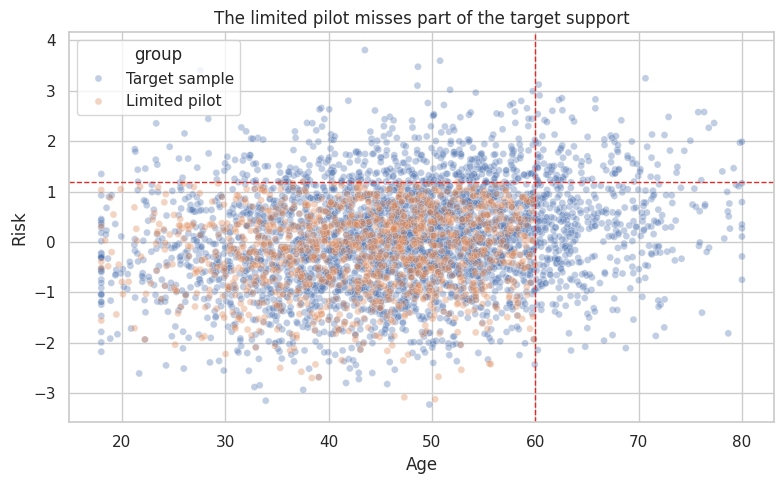

In [20]:
target_sample = target.sample(3500, random_state=12).assign(group="Target sample")
pilot_sample = limited_trial.sample(min(1200, len(limited_trial)), random_state=13).assign(group="Limited pilot")
support_plot = pd.concat([target_sample, pilot_sample], ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=support_plot,
    x="age",
    y="risk",
    hue="group",
    alpha=0.35,
    s=25,
    ax=ax,
)
ax.axvline(60, color="#de2d26", linestyle="--", linewidth=1)
ax.axhline(1.20, color="#de2d26", linestyle="--", linewidth=1)
ax.set_title("The limited pilot misses part of the target support")
ax.set_xlabel("Age")
ax.set_ylabel("Risk")
plt.tight_layout()
plt.show()


When support is poor, the honest conclusion may be:

> The pilot provides credible evidence for the covered portion of the target population, but not for the full deployment population.

That conclusion is often more valuable than a polished but unsupported transported estimate.


## 14. Extrapolation Risk

Let us try to standardize from the limited pilot anyway. The model must extrapolate into older and higher-risk regions where the pilot has no observations.


In [21]:
limited_model = smf.ols(
    "Y_limited ~ A_limited * (age + risk + enterprise + prior_usage)",
    data=limited_trial,
).fit()

limited_standardized = (
    limited_model.predict(target.assign(A_limited=1.0))
    - limited_model.predict(target.assign(A_limited=0.0))
).mean()

limited_estimand_table = pd.DataFrame(
    [
        {"estimand_or_estimator": "True target ATE", "estimate": target["tau"].mean()},
        {
            "estimand_or_estimator": "True support-covered target ATE",
            "estimate": target.loc[target["pilot_support"], "tau"].mean(),
        },
        {
            "estimand_or_estimator": "Limited pilot difference",
            "estimate": mean_difference(limited_trial, "Y_limited", "A_limited"),
        },
        {
            "estimand_or_estimator": "Limited-pilot standardization to full target",
            "estimate": limited_standardized,
        },
    ]
)
limited_estimand_table["error_vs_true_target"] = limited_estimand_table["estimate"] - target["tau"].mean()
limited_estimand_table


,estimand_or_estimator,estimate,error_vs_true_target
0,True target ATE,2.599,0.000
1,True support-covered target ATE,2.955,0.356
2,Limited pilot difference,2.968,0.369
3,Limited-pilot standardization to full target,2.609,0.010


This example may look acceptable because the simulated outcome model is relatively friendly. In real applications, extrapolation into uncovered segments is where failures often occur. The problem is not only statistical uncertainty. The intervention may work through different mechanisms in the uncovered segment.


## 15. Sensitivity to an Unmeasured Effect Modifier

The key assumption:

$$
Y(a) \perp S \mid X
$$

fails if an unmeasured effect modifier differs between the trial and target population.

Suppose there is an unmeasured implementation-readiness score $U$ that changes the treatment effect by $\gamma$ per unit. If the target population has mean $U$ that differs from the weighted trial by $\Delta_U$, then a rough bias term is:

$$
Bias \approx \gamma \Delta_U
$$

We can use a grid to ask how large this problem must be to change the decision.


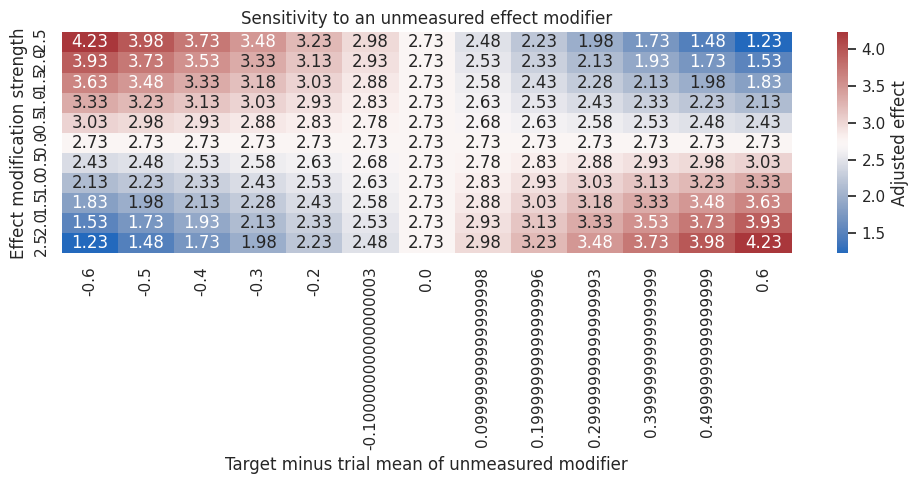

In [22]:
gamma_grid = np.linspace(-2.5, 2.5, 11)
delta_grid = np.linspace(-0.6, 0.6, 13)

sensitivity_rows = []
for gamma in gamma_grid:
    for delta_u in delta_grid:
        sensitivity_rows.append(
            {
                "gamma_effect_modification": gamma,
                "delta_u_target_minus_trial": delta_u,
                "bias": gamma * delta_u,
                "sensitivity_adjusted_effect": dr_estimate + gamma * delta_u,
            }
        )

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_pivot = sensitivity_df.pivot(
    index="gamma_effect_modification",
    columns="delta_u_target_minus_trial",
    values="sensitivity_adjusted_effect",
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    sensitivity_pivot,
    cmap="vlag",
    center=dr_estimate,
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Adjusted effect"},
    ax=ax,
)
ax.set_title("Sensitivity to an unmeasured effect modifier")
ax.set_xlabel("Target minus trial mean of unmeasured modifier")
ax.set_ylabel("Effect modification strength")
plt.tight_layout()
plt.show()


Sensitivity analysis is not an admission of failure. It is a decision tool.

If the business decision would be the same across plausible values of $\gamma$ and $\Delta_U$, the result is more robust. If the decision changes under modest unmeasured heterogeneity, the next step should be better measurement or a broader pilot.


## 16. Multi-Site Transportability

Many industry studies are not single trials. They are pilots across markets, stores, warehouses, sales teams, hospitals, or regions.

Site-level features can modify effects:

$$
\tau_{ij} = \tau(X_{ij}, Z_j)
$$

where $X_{ij}$ are unit-level covariates and $Z_j$ are site-level covariates.

Ignoring site composition can make a successful pilot look more scalable than it is.


In [23]:
rng = np.random.default_rng(4511)
sites = pd.DataFrame(
    {
        "site": [f"site_{i:02d}" for i in range(1, 31)],
        "digital_maturity": rng.normal(0, 1, size=30),
        "region_cost": rng.normal(0, 1, size=30),
    }
)
sites["site_size"] = rng.integers(500, 2500, size=30)
sites["pilot_site"] = sites["digital_maturity"] > sites["digital_maturity"].quantile(0.58)

site_population = sites.loc[sites.index.repeat(sites["site_size"])].reset_index(drop=True)
site_population["customer_risk"] = rng.normal(0.2 * site_population["region_cost"], 1.0)
site_population["site_tau"] = (
    1.8
    + 0.9 * site_population["digital_maturity"]
    - 0.5 * site_population["customer_risk"]
)
site_population["Y0"] = (
    15
    + 1.5 * site_population["digital_maturity"]
    - 1.2 * site_population["customer_risk"]
    + rng.normal(0, 3.0, size=len(site_population))
)
site_population["S"] = site_population["pilot_site"].astype(int)
site_population["A"] = np.where(site_population["S"] == 1, rng.binomial(1, 0.5, size=len(site_population)), np.nan)
site_population["Y"] = np.where(
    site_population["S"] == 1,
    site_population["Y0"] + site_population["A"] * site_population["site_tau"],
    np.nan,
)

site_trial = site_population.loc[site_population["S"] == 1].copy()

site_summary = pd.Series(
    {
        "number_of_sites": sites.shape[0],
        "pilot_sites": sites["pilot_site"].sum(),
        "target_ate_all_sites": site_population["site_tau"].mean(),
        "pilot_site_sate": site_trial["site_tau"].mean(),
        "observed_pilot_difference": mean_difference(site_trial, "Y", "A"),
        "target_mean_digital_maturity": site_population["digital_maturity"].mean(),
        "pilot_mean_digital_maturity": site_trial["digital_maturity"].mean(),
    }
)

site_summary


number_of_sites                30.000
pilot_sites                    13.000
target_ate_all_sites            1.758
pilot_site_sate                 2.399
observed_pilot_difference       2.394
target_mean_digital_maturity   -0.017
pilot_mean_digital_maturity     0.664
dtype: float64

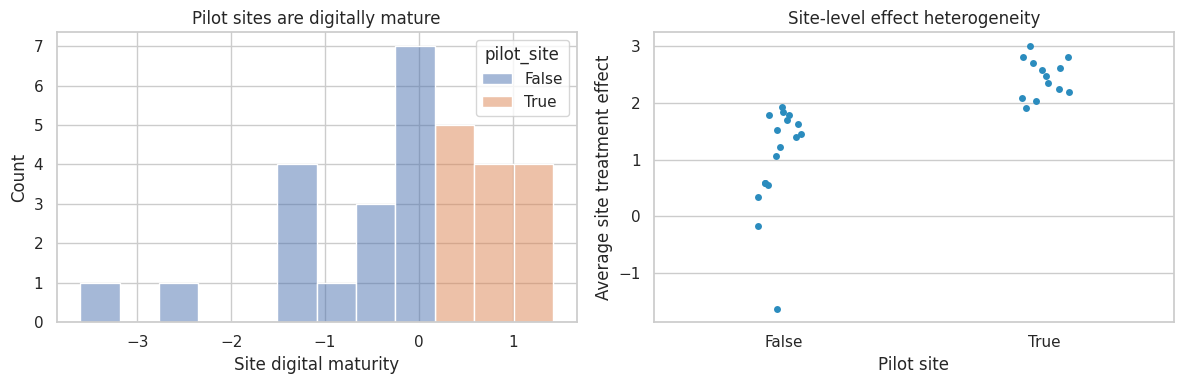

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=sites, x="digital_maturity", hue="pilot_site", bins=12, ax=axes[0])
axes[0].set_title("Pilot sites are digitally mature")
axes[0].set_xlabel("Site digital maturity")

site_effects = site_population.groupby(["site", "pilot_site"], as_index=False)["site_tau"].mean()
sns.stripplot(data=site_effects, x="pilot_site", y="site_tau", ax=axes[1], color="#2b8cbe")
axes[1].set_title("Site-level effect heterogeneity")
axes[1].set_xlabel("Pilot site")
axes[1].set_ylabel("Average site treatment effect")

plt.tight_layout()
plt.show()


The pilot is internally valid for digitally mature sites. But a national rollout needs evidence for lower-maturity sites too. The design response might be to deliberately include sites across the deployment distribution, not only the easiest sites.


## 17. What to Report

A transportability analysis should not report only one number. It should report:


In [25]:
reporting_table = pd.DataFrame(
    [
        {
            "component": "Target population",
            "report": "Who is the effect meant to apply to?",
            "example": "All eligible SMB and enterprise customers in the next-quarter rollout.",
        },
        {
            "component": "Study sample",
            "report": "Who was actually studied?",
            "example": "Pilot users from US enterprise accounts with high prior usage.",
        },
        {
            "component": "Effect modifiers",
            "report": "Which variables could change treatment effects?",
            "example": "Risk, account size, region, prior usage, implementation maturity.",
        },
        {
            "component": "Balance and overlap",
            "report": "How well does the study cover the target population?",
            "example": "Weighted SMDs and support plots.",
        },
        {
            "component": "Transport estimator",
            "report": "How was the target effect estimated?",
            "example": "Outcome standardization plus sampling-weight sensitivity check.",
        },
        {
            "component": "Sensitivity analysis",
            "report": "Could unmeasured modifiers change the decision?",
            "example": "Grid over unmeasured readiness differences and effect modification strength.",
        },
        {
            "component": "Decision boundary",
            "report": "What effect size would change the action?",
            "example": "Launch if expected renewal lift exceeds 1.5 percentage points.",
        },
    ]
)

reporting_table


,component,report,example
0,Target population,Who is the effect meant to apply to?,All eligible SMB and enterprise customers in t...
1,Study sample,Who was actually studied?,Pilot users from US enterprise accounts with h...
2,Effect modifiers,Which variables could change treatment effects?,"Risk, account size, region, prior usage, imple..."
3,Balance and overlap,How well does the study cover the target popul...,Weighted SMDs and support plots.
4,Transport estimator,How was the target effect estimated?,Outcome standardization plus sampling-weight s...
5,Sensitivity analysis,Could unmeasured modifiers change the decision?,Grid over unmeasured readiness differences and...
6,Decision boundary,What effect size would change the action?,Launch if expected renewal lift exceeds 1.5 pe...


## 18. Industry Decision Memo Example

Here is a concise external-validity memo for a product or operations decision.


In [26]:
memo = '''
### External-Validity Memo

**Decision.** Decide whether to roll out the retention intervention from the pilot to all eligible accounts.

**Study estimate.** The pilot estimate is internally valid for pilot participants because treatment was randomized.

**Target population.** The deployment population includes older, higher-risk, lower-usage accounts that were underrepresented in the pilot.

**Main external-validity risk.** Risk and prior usage appear to modify the treatment effect. The pilot overrepresents customers with higher expected responsiveness.

**Transport analysis.**

- Fit a sampling model for pilot participation using age, risk, enterprise status, and prior usage.
- Check trial-target balance before and after inverse sampling weights.
- Estimate the target effect using outcome standardization and inverse sampling weighting.
- Use a doubly robust estimator as the primary transported estimate.

**Support concern.** The pilot has limited coverage for the oldest and highest-risk accounts. We should not claim strong evidence for that segment.

**Sensitivity analysis.** Test whether unmeasured implementation readiness could erase the transported effect.

**Recommendation.** Roll out to the population covered by the pilot support, and run a deliberately broadened second pilot for high-risk accounts before full deployment.
'''.strip()

display(Markdown(memo))


### External-Validity Memo

**Decision.** Decide whether to roll out the retention intervention from the pilot to all eligible accounts.

**Study estimate.** The pilot estimate is internally valid for pilot participants because treatment was randomized.

**Target population.** The deployment population includes older, higher-risk, lower-usage accounts that were underrepresented in the pilot.

**Main external-validity risk.** Risk and prior usage appear to modify the treatment effect. The pilot overrepresents customers with higher expected responsiveness.

**Transport analysis.**

- Fit a sampling model for pilot participation using age, risk, enterprise status, and prior usage.
- Check trial-target balance before and after inverse sampling weights.
- Estimate the target effect using outcome standardization and inverse sampling weighting.
- Use a doubly robust estimator as the primary transported estimate.

**Support concern.** The pilot has limited coverage for the oldest and highest-risk accounts. We should not claim strong evidence for that segment.

**Sensitivity analysis.** Test whether unmeasured implementation readiness could erase the transported effect.

**Recommendation.** Roll out to the population covered by the pilot support, and run a deliberately broadened second pilot for high-risk accounts before full deployment.

## 19. Common Failure Modes

1. Reporting a randomized trial estimate as if it automatically applies everywhere.
2. Comparing trial and target populations on prognostic variables but ignoring effect modifiers.
3. Using weights without checking overlap or extreme weights.
4. Standardizing into target regions where the study has no support.
5. Treating a convenience pilot as a random sample from the deployment population.
6. Forgetting that interventions can change across environments.
7. Ignoring site-level heterogeneity in multi-site pilots.
8. Reporting statistical uncertainty but not external-validity uncertainty.


## 20. Exercises

1. Change the pilot participation model so high-risk customers are more likely to enter the pilot. How does the trial SATE compare with the target ATE?
2. Remove treatment-effect heterogeneity by setting `target["tau"] = 2.4`. Which estimators change?
3. Add an interaction between treatment and `risk ** 2` to the true effect, but keep the linear outcome model. How does model misspecification affect standardization?
4. Trim transport weights above the 99th percentile. How does the IPW estimate change?
5. In the limited-support example, design a second pilot sample that covers the unsupported region.
6. For your own project, define the target population before looking at the experimental estimate. Which units are in and out?


## 21. Key Takeaways

- Randomization protects internal validity, not external validity.
- The trial-sample effect and target-population effect differ when study participation changes the distribution of effect modifiers.
- Standardization re-averages conditional treatment effects over the target population.
- Inverse probability of sampling weights reweight the trial to look like the target population.
- Subclassification is transparent and useful when sampling scores summarize trial-target differences well.
- Doubly robust estimators combine an outcome model with a sampling model.
- Overlap and support diagnostics are essential. If the target contains profiles absent from the trial, the analysis becomes extrapolation.
- In industry settings, the right recommendation may be partial rollout plus a better-designed second pilot.


## References

Bareinboim, E., & Pearl, J. (2011). Transportability of causal and statistical relations: A formal approach. *Proceedings of the AAAI Conference on Artificial Intelligence, 25*(1), 247-254. https://doi.org/10.1609/aaai.v25i1.7861

Buchanan, A. L., Hudgens, M. G., Cole, S. R., Mollan, K. R., Sax, P. E., Daar, E. S., Adimora, A. A., Eron, J. J., & Mugavero, M. J. (2018). Generalizing evidence from randomized trials using inverse probability of sampling weights. *Journal of the Royal Statistical Society: Series A, 181*(4), 1193-1209. https://doi.org/10.1111/rssa.12357

Cole, S. R., & Stuart, E. A. (2010). Generalizing evidence from randomized clinical trials to target populations: The ACTG 320 trial. *American Journal of Epidemiology, 172*(1), 107-115. https://doi.org/10.1093/aje/kwq084

Dahabreh, I. J., Haneuse, S. J.-P. A., Robins, J. M., Robertson, S. E., Buchanan, A. L., Stuart, E. A., & Hernan, M. A. (2021). Study designs for extending causal inferences from a randomized trial to a target population. *American Journal of Epidemiology, 190*(8), 1632-1642. https://doi.org/10.1093/aje/kwaa270

Tipton, E. (2013). Improving generalizations from experiments using propensity score subclassification: Assumptions, properties, and contexts. *Journal of Educational and Behavioral Statistics, 38*(3), 239-266. https://doi.org/10.3102/1076998612441947
